In [2]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load and parse dates
df = pd.read_csv('PM_Modi_speeches.csv')
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# 2. Basic Text Cleaning
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation & numbers
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

# 3. Extract Era-Specific Phrases via TF-IDF (Bigrams & Trigrams)
# We group by year to find phrases unique to specific periods
yearly_jargon = {}

for year, group in df.groupby('year'):
    # Join all speeches from that year
    combined_text = " ".join(group['cleaned_text'])

    # Configure TF-IDF for phrase ranges (2 to 3 words)
    vectorizer = TfidfVectorizer(ngram_range=(2, 3), stop_words='english', max_features=15)
    tfidf_matrix = vectorizer.fit_transform([combined_text])

    # Get top phrases
    feature_names = vectorizer.get_feature_names_out()
    yearly_jargon[year] = list(feature_names)

# View candidate phrases
for year, phrases in sorted(yearly_jargon.items()):
    print(f"Year {year} Candidates: {phrases[:5]}")

Year 2014 Candidates: ['brothers sisters', 'digital india', 'east north', 'east north east', 'human resource development']
Year 2015 Candidates: ['brothers sisters', 'central asia', 'clean energy', 'climate change', 'digital india']
Year 2016 Candidates: ['black money', 'brothers sisters', 'dear countrymen', 'ki baat', 'ladies gentlemen']
Year 2017 Candidates: ['brothers sisters', 'dear countrymen', 'doing business', 'good governance', 'ki baat']
Year 2018 Candidates: ['artificial intelligence', 'brothers sisters', 'dear countrymen', 'doing business', 'ease doing']
Year 2019 Candidates: ['ayushman bharat', 'brothers sisters', 'dear countrymen', 'doing business', 'friends today']
Year 2020 Candidates: ['best wishes', 'brothers sisters', 'corona pandemic', 'crore rupees', 'dear countrymen']


In [3]:
import json

# Consolidate all unique phrases extracted from step 1
unique_phrases = list(set([phrase for phrases in yearly_jargon.values() for phrase in phrases]))

llm_prompt = f"""
You are an expert political scientist and computational linguist.
Categorize the following historical/political phrases into exactly one of these three functional buckets:
1. Economic Ideology (e.g., development, self-reliance, infrastructure, markets)
2. Security/Sovereignty (e.g., defense, digital sovereignty, borders, national pride)
3. Welfare/Inclusion (e.g., poverty alleviation, healthcare, rural support, youth empowerment)

Return your response ONLY as a valid JSON object where keys are the phrases and values are the bucket names.

Phrases to categorize:
{unique_phrases}
"""

print(llm_prompt)
# Send 'llm_prompt' to your chosen LLM API here.
# Parse the returned JSON into a dictionary: phrase_mapping = json.loads(api_response)


You are an expert political scientist and computational linguist.
Categorize the following historical/political phrases into exactly one of these three functional buckets:
1. Economic Ideology (e.g., development, self-reliance, infrastructure, markets)
2. Security/Sovereignty (e.g., defense, digital sovereignty, borders, national pride)
3. Welfare/Inclusion (e.g., poverty alleviation, healthcare, rural support, youth empowerment)

Return your response ONLY as a valid JSON object where keys are the phrases and values are the bucket names.

Phrases to categorize:
['mahatma gandhi', 'united nations', 'mobile phone', 'ki baat', 'south africa', 'lord rama', 'artificial intelligence', 'sri lanka', 'make india', 'north east north', 'international solar', 'clean energy', 'soil health', 'selfreliant india', 'best wishes', 'black money', 'look forward', 'st century', 'mann ki baat', 'ladies gentlemen', 'digital india', 'central asia', 'north eastern', 'education policy', 'international solar al

In [4]:
# Install any missing libraries (standard Colab environments usually have these, but safe to include)
!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

print("Dependencies imported successfully!")

Dependencies imported successfully!


In [5]:
# 1. Load the dataset (Trying alternative encodings to catch non-standard characters)
try:
    # Using latin-1 encoding captures a wider range of character sets without throwing errors
    df = pd.read_csv('PM_Modi_speeches.csv', encoding='latin-1')
    print(f"Successfully loaded dataset with {len(df)} rows!")
except FileNotFoundError:
    print("Error: 'PM_Modi_speeches.csv' not found. Please upload it to the Colab files section tab on the left.")
except Exception as e:
    print(f"Fallback reading method triggered due to: {e}")
    # Final fallback: open with utf-8 but ignore problematic bytes safely
    df = pd.read_csv('PM_Modi_speeches.csv', encoding='utf-8', on_bad_lines='skip')
    print(f"Loaded dataset with bad lines skipped. Rows: {len(df)}")

# 2. Parse date and extract Year
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year

# 3. Clean text for natural processing
def clean_text(text):
    if not isinstance(text, str):
        return ""
    return text.lower()

df['cleaned_text'] = df['text'].apply(clean_text)
print("Text preprocessing completed.")

Successfully loaded dataset with 922 rows!
Text preprocessing completed.


In [7]:
# Defined correctly by removing the extra outer set of curly braces
phrase_mapping = {
    "central asia": "Security/Sovereignty",
    "crore rupees": "Economic Ideology",
    "north eastern": "Welfare/Inclusion",
    "united nations": "Security/Sovereignty",
    "north east north": "Welfare/Inclusion",
    "team india": "Security/Sovereignty",
    "black money": "Economic Ideology",
    "selfreliant india": "Economic Ideology",
    "mahatma gandhi": "Welfare/Inclusion",
    "best wishes": "Welfare/Inclusion",
    "soil health": "Welfare/Inclusion",
    "digital india": "Economic Ideology",
    "years ago": "Economic Ideology",
    "today india": "Security/Sovereignty",
    "st century": "Economic Ideology",
    "brothers sisters": "Welfare/Inclusion",
    "doing business": "Economic Ideology",
    "mann ki": "Welfare/Inclusion",
    "modi ji": "Welfare/Inclusion",
    "ki baat": "Welfare/Inclusion",
    "skill development": "Welfare/Inclusion",
    "jammu kashmir": "Security/Sovereignty",
    "renewable energy": "Economic Ideology",
    "medical science": "Welfare/Inclusion",
    "east north": "Welfare/Inclusion",
    "resource development": "Economic Ideology",
    "mann ki baat": "Welfare/Inclusion",
    "prime minister": "Security/Sovereignty",
    "education policy": "Welfare/Inclusion",
    "mobile phone": "Economic Ideology",
    "ease doing business": "Economic Ideology",
    "ladies gentlemen": "Welfare/Inclusion",
    "south africa": "Security/Sovereignty",
    "lord rama": "Security/Sovereignty",
    "friends today": "Welfare/Inclusion",
    "international solar alliance": "Economic Ideology",
    "solar alliance": "Economic Ideology",
    "look forward": "Welfare/Inclusion",
    "new india": "Economic Ideology",
    "sri lanka": "Security/Sovereignty",
    "north east": "Welfare/Inclusion",
    "artificial intelligence": "Economic Ideology",
    "climate change": "Economic Ideology",
    "dear countrymen": "Welfare/Inclusion",
    "guru nanak": "Welfare/Inclusion",
    "east north east": "Welfare/Inclusion",
    "ayushman bharat": "Welfare/Inclusion",
    "good governance": "Welfare/Inclusion",
    "make india": "Economic Ideology",
    "uttar pradesh": "Welfare/Inclusion",
    "ease doing": "Economic Ideology",
    "international solar": "Economic Ideology",
    "clean energy": "Economic Ideology",
    "corona pandemic": "Welfare/Inclusion",
    "human resource development": "Welfare/Inclusion"
}

print(f"Mapped {len(phrase_mapping)} candidate jargon terms into political dimensions.")

Mapped 55 candidate jargon terms into political dimensions.


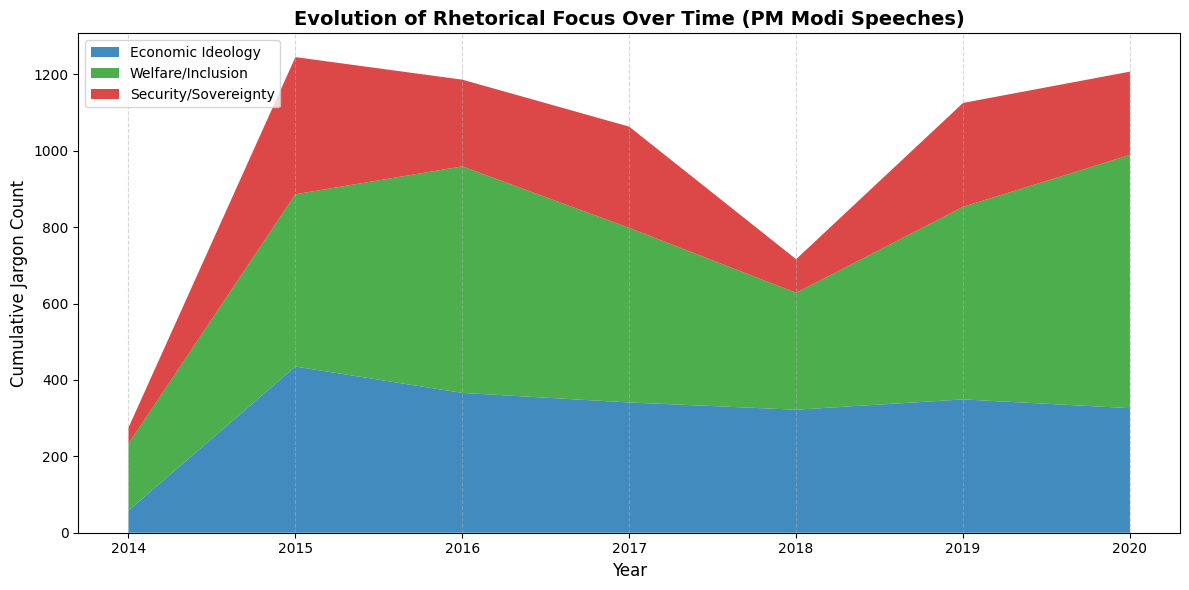

In [8]:
# Initialize a list to hold phrase occurrences per speech
era_data = []

for idx, row in df.iterrows():
    year = row['year']
    text = row['cleaned_text']

    # Base count framework for this specific speech
    counts = {'Economic Ideology': 0, 'Security/Sovereignty': 0, 'Welfare/Inclusion': 0}

    # Evaluate raw count frequencies
    for phrase, category in phrase_mapping.items():
        occurrences = text.count(phrase)
        counts[category] += occurrences

    counts['year'] = year
    era_data.append(counts)

# Group structural counts by year
df_era = pd.DataFrame(era_data).groupby('year').sum().reset_index()

# Plot Stacked Area Chart natively inside Colab
plt.figure(figsize=(12, 6))
plt.stackplot(df_era['year'],
              df_era['Economic Ideology'],
              df_era['Welfare/Inclusion'],
              df_era['Security/Sovereignty'],
              labels=['Economic Ideology', 'Welfare/Inclusion', 'Security/Sovereignty'],
              colors=['#1f77b4', '#2ca02c', '#d62728'], alpha=0.85)

plt.title("Evolution of Rhetorical Focus Over Time (PM Modi Speeches)", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Cumulative Jargon Count", fontsize=12)
plt.legend(loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Render plot in notebook
plt.show()

In [9]:
# Function to calculate Shannon Entropy (Lexical Complexity)
def calculate_shannon_entropy(text):
    words = re.sub(r'[^a-zA-Z\s]', '', text).split()
    if not words:
        return 0
    counts = Counter(words)
    frequencies = [count / len(words) for count in counts.values()]
    return -sum(p * np.log2(p) for p in frequencies)

# Function to run structural pacing and pronoun profiling
def analyze_fingerprint(row):
    raw_text = row['text']
    cleaned_text = row['cleaned_text']
    words = re.sub(r'[^a-zA-Z\s]', '', cleaned_text).split()
    total_words = len(words) if len(words) > 0 else 1

    # Target pronouns
    i_me_my = words.count('i') + words.count('me') + words.count('my') + words.count('myself')
    we_us_our = words.count('we') + words.count('us') + words.count('our') + words.count('ourselves')

    # Calculate average sentence metrics
    sentences = re.split(r'[.!?]+', raw_text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]
    avg_sentence_len = total_words / len(sentences) if len(sentences) > 0 else 0

    return pd.Series({
        'Lexical_Entropy': calculate_shannon_entropy(cleaned_text),
        'I_Ratio (%)': (i_me_my / total_words) * 100,
        'We_Ratio (%)': (we_us_our / total_words) * 100,
        'Avg_Sentence_Length': avg_sentence_len
    })

# Compute metrics across the entire dataset matrix
print("Calculating linguistic features... (This might take a brief moment depending on notebook CPU configuration)")
fingerprint_df = df.apply(analyze_fingerprint, axis=1)

# Merge back and aggregate by political era (Year)
df_stylistic = pd.concat([df, fingerprint_df], axis=1)
stylistic_evolution = df_stylistic.groupby('year')[['Lexical_Entropy', 'I_Ratio (%)', 'We_Ratio (%)', 'Avg_Sentence_Length']].mean()

# Display styled DataFrame cleanly inside Colab
print("\n--- STYLISTIC FINGERPRINT EVOLUTION MATRIX ---")
display(stylistic_evolution.round(2))

Calculating linguistic features... (This might take a brief moment depending on notebook CPU configuration)

--- STYLISTIC FINGERPRINT EVOLUTION MATRIX ---


,Lexical_Entropy,I_Ratio (%),We_Ratio (%),Avg_Sentence_Length
year,,,,
2014,5.74,0.66,1.14,12.95
2015,6.52,1.01,1.90,15.09
2016,6.14,0.81,1.60,17.63
2017,6.50,0.72,1.40,20.22
2018,6.20,0.54,0.83,22.00
2019,6.61,1.36,1.51,15.67
2020,7.74,1.14,2.12,16.58
